In [1]:
!pip install aif360

In [ ]:
!pip install aif360[AdversarialDebiasing]

In [ ]:
!pip install aif360[Reductions]
!pip install aif360[inFairness]

In [12]:
#Loading Cleaned Data and turning attributes into numeric

import pandas as pd
import numpy as np

df = pd.read_csv("SelectedClean_nhis2023.csv")

df['ANXEV_A'] = df['ANXEV_A'].map({'Yes': 1, 'No': 0}).astype(int)
df['SEX_A'] = df['SEX_A'].map({'Male': 0, 'Female': 1}).astype(int)
df['HISPALLP_BIN'] = df['HISPALLP_A'].map({
    'Non-Hispanic White only': 1,  
    'Hispanic': 0,
    'Non-Hispanic Black/African American only': 0,
    'Non-Hispanic Asian only': 0,
    'Non-Hispanic AIAN only': 0,
    'Non-Hispanic AIAN and any other group': 0,
    'Multiple races': 0
}).astype(int)

df_aif = df.copy().reset_index().rename(columns={"index": "row_id"})

print(df_aif.head())

   row_id                                HISPALLP_A  SEX_A  AGEP_A  ANXEV_A  \
0       0  Non-Hispanic Black/African American only      0      67        0   
1       1                   Non-Hispanic White only      0      73        0   
2       2  Non-Hispanic Black/African American only      0      48        0   
3       3                   Non-Hispanic White only      1      42        0   
4       4                   Non-Hispanic White only      1      50        0   

   HISPALLP_BIN  
0             0  
1             1  
2             0  
3             1  
4             1  


In [4]:
#Measuring Fairness metrics before reweghing

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric

def dataset_fairness_metrics(df, label_attr, protected_attr):
    """Compute fairness metrics before reweighing"""
    
    # Create BinaryLabelDataset for AIF360
    dataset = BinaryLabelDataset(
        favorable_label=1,
        unfavorable_label=0,
        df=df[[label_attr, protected_attr]],
        label_names=[label_attr],
        protected_attribute_names=[protected_attr]
    )
    
    metric = BinaryLabelDatasetMetric(
        dataset,
        unprivileged_groups=[{protected_attr: 0}],
        privileged_groups=[{protected_attr: 1}]
    )
    
    print(f"\nFairness Metrics for {protected_attr}:")
    print("Mean Difference:", metric.mean_difference())
    print("Disparate Impact:", metric.disparate_impact())
    print("Statistical Parity Difference:", metric.statistical_parity_difference())
    
    return metric

print("=== Before Reweighing (SEX_A) ===")
dataset_fairness_metrics(df_aif, label_attr='ANXEV_A', protected_attr='SEX_A')

print("\n=== Before Reweighing (HISPALLP_BIN) ===")
dataset_fairness_metrics(df_aif, label_attr='ANXEV_A', protected_attr='HISPALLP_BIN')

2025-08-17 15:30:02.977195: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755441003.154020    1036 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755441003.203283    1036 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755441003.565485    1036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755441003.565604    1036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755441003.565610    1036 computation_placer.cc:177] computation placer alr

=== Before Reweighing (SEX_A) ===

Fairness Metrics for SEX_A:
Mean Difference: -0.10099543750744483
Disparate Impact: 0.5612950827534915
Statistical Parity Difference: -0.10099543750744483

=== Before Reweighing (HISPALLP_BIN) ===

Fairness Metrics for HISPALLP_BIN:
Mean Difference: -0.07523044155422362
Disparate Impact: 0.6413093677562961
Statistical Parity Difference: -0.07523044155422362


In [13]:
#Reweighing protected attributes

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

def safe_reweighing(df, label_attr, protected_attr, fav_label=1, unfav_label=0):
    print(f"\nChecking {protected_attr} for empty groups...")
    cross_tab = pd.crosstab(df[protected_attr], df[label_attr])
    print(cross_tab)

    # Remove categories that lack representation
    valid_categories = cross_tab[(cross_tab[fav_label] > 0) & (cross_tab[unfav_label] > 0)].index.tolist()
    df = df[df[protected_attr].isin(valid_categories)]

    dataset_orig = BinaryLabelDataset(
        favorable_label=fav_label,
        unfavorable_label=unfav_label,
        df=df[["row_id", label_attr, protected_attr]],
        label_names=[label_attr],
        protected_attribute_names=[protected_attr]
    )

    RW = Reweighing(unprivileged_groups=[{protected_attr: valid_categories[0]}],
                    privileged_groups=[{protected_attr: valid_categories[1]}])
    dataset_transf = RW.fit_transform(dataset_orig)

    df_balanced, _ = dataset_transf.convert_to_dataframe()
    df_balanced["instance_weight"] = dataset_transf.instance_weights
    
    print(f"Finished reweighing for {protected_attr}")
    return dataset_transf, df_balanced


    # Run reweighing 
ds_sex_balanced, df_sex_balanced = safe_reweighing(df_aif, "ANXEV_A", "SEX_A")
ds_hisp_balanced, df_hisp_balanced = safe_reweighing(df_aif, "ANXEV_A", "HISPALLP_BIN")

# Merge weights back into full dataset
df_sex_full = df_aif.merge(df_sex_balanced[["row_id", "instance_weight"]], on="row_id", how="left")
df_hisp_full = df_aif.merge(df_hisp_balanced[["row_id", "instance_weight"]], on="row_id", how="left")


Checking SEX_A for empty groups...
ANXEV_A      0     1
SEX_A               
0        11692  1735
1        12342  3691
Finished reweighing for SEX_A

Checking HISPALLP_BIN for empty groups...
ANXEV_A           0     1
HISPALLP_BIN             
0              8661  1346
1             15373  4080
Finished reweighing for HISPALLP_BIN


In [14]:
print(df_sex_balanced.head())
print(df_hisp_balanced.head())


   row_id  SEX_A  ANXEV_A  instance_weight
0     0.0    0.0      0.0         0.936879
1     1.0    0.0      0.0         0.936879
2     2.0    0.0      0.0         0.936879
3     3.0    1.0      0.0         1.059797
4     4.0    1.0      0.0         1.059797
   row_id  HISPALLP_BIN  ANXEV_A  instance_weight
0     0.0           0.0      0.0         0.942604
1     1.0           1.0      0.0         1.032336
2     2.0           0.0      0.0         0.942604
3     3.0           1.0      0.0         1.032336
4     4.0           1.0      0.0         1.032336


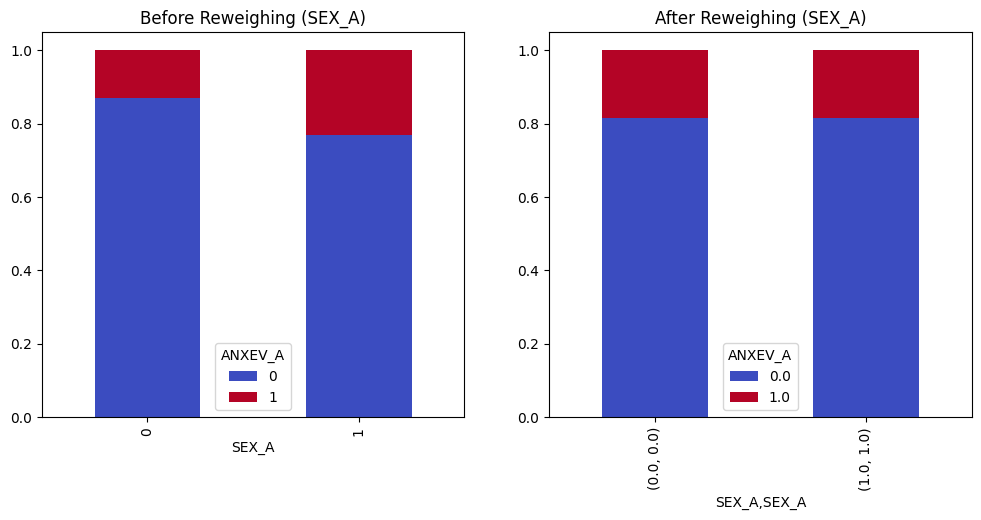

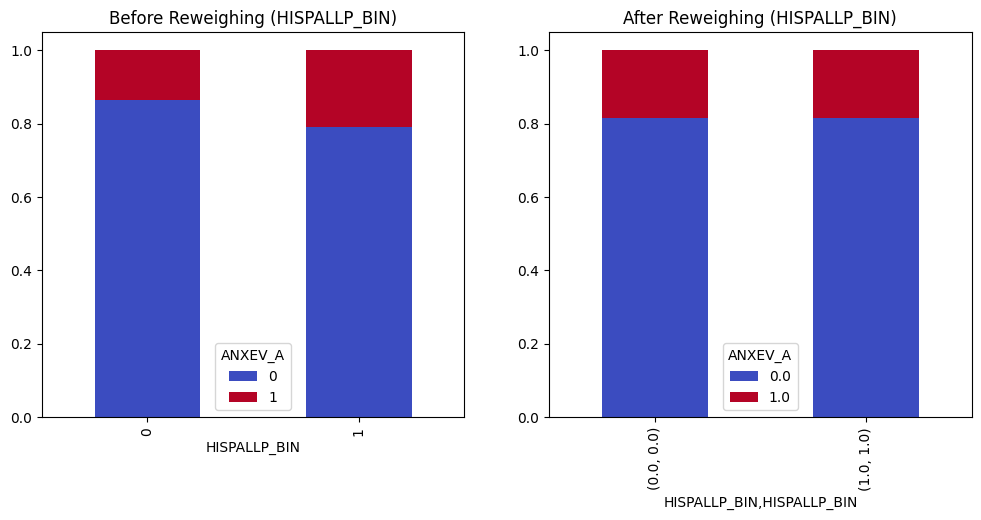

In [15]:
#Compare before vs. after reweighing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def compare_before_after(original_df, balanced_ds, target, protected):
    before = pd.crosstab(original_df[protected], original_df[target], normalize="index")

    df_balanced, _ = balanced_ds.convert_to_dataframe()
    weights = balanced_ds.instance_weights
    
    after = (
        df_balanced
        .assign(weights=weights)
        .groupby([protected, target])['weights']
        .sum()
        .groupby(level=0)
        .apply(lambda x: x / x.sum())
        .unstack(fill_value=0)
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    before.plot(kind="bar", stacked=True, ax=axes[0], colormap="coolwarm")
    axes[0].set_title(f"Before Reweighing ({protected})")
    after.plot(kind="bar", stacked=True, ax=axes[1], colormap="coolwarm")
    axes[1].set_title(f"After Reweighing ({protected})")
    plt.show()

   # Compare visualizations
compare_before_after(df_aif, ds_sex_balanced, "ANXEV_A", "SEX_A")
compare_before_after(df_aif, ds_hisp_balanced, "ANXEV_A", "HISPALLP_BIN")

In [16]:
#Measuring Fairness metrics after reweghing
from aif360.metrics import BinaryLabelDatasetMetric

def dataset_fairness_metrics_aif(dataset, protected_attr):
    """Compute fairness metrics from an AIF360 BinaryLabelDataset"""
    metric = BinaryLabelDatasetMetric(
        dataset,
        unprivileged_groups=[{protected_attr: 0}],
        privileged_groups=[{protected_attr: 1}]
    )
    
    print(f"\nFairness Metrics for {protected_attr}:")
    print("Mean Difference:", metric.mean_difference())
    print("Disparate Impact:", metric.disparate_impact())
    print("Statistical Parity Difference:", metric.statistical_parity_difference())
    
    return metric


print("\nAfter Reweighing:")
dataset_fairness_metrics_aif(ds_sex_balanced, "SEX_A")

print("\nAfter Reweighing:")
dataset_fairness_metrics_aif(ds_hisp_balanced, "HISPALLP_BIN")

    
    


After Reweighing:

Fairness Metrics for SEX_A:
Mean Difference: 2.7755575615628914e-17
Disparate Impact: 1.0000000000000002
Statistical Parity Difference: 2.7755575615628914e-17

After Reweighing:

Fairness Metrics for HISPALLP_BIN:
Mean Difference: 0.0
Disparate Impact: 1.0
Statistical Parity Difference: 0.0


In [17]:
#Comparison metrics before and after reweghing

import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric

def collect_fairness_comparison(df_before, ds_after, label_attr, protected_attr, fav_label=1, unfav_label=0):

    # --- Before (DataFrame version) ---
    cross_tab = pd.crosstab(df_before[protected_attr], df_before[label_attr])
    print(f"\nChecking counts for {protected_attr} before reweighing:\n", cross_tab)

    # Build AIF dataset for BEFORE
    from aif360.datasets import BinaryLabelDataset
    dataset_before = BinaryLabelDataset(
        favorable_label=fav_label,
        unfavorable_label=unfav_label,
        df=df_before[[label_attr, protected_attr]],
        label_names=[label_attr],
        protected_attribute_names=[protected_attr]
    )

    # Metrics before
    metric_before = BinaryLabelDatasetMetric(
        dataset_before,
        unprivileged_groups=[{protected_attr: 0}],
        privileged_groups=[{protected_attr: 1}]
    )

    # Metrics after
    metric_after = BinaryLabelDatasetMetric(
        ds_after,
        unprivileged_groups=[{protected_attr: 0}],
        privileged_groups=[{protected_attr: 1}]
    )

    # Collect results
    results = pd.DataFrame({
        "Metric": ["Mean Difference", "Disparate Impact", "Statistical Parity Difference"],
        "Before": [metric_before.mean_difference(),
                   metric_before.disparate_impact(),
                   metric_before.statistical_parity_difference()],
        "After": [metric_after.mean_difference(),
                  metric_after.disparate_impact(),
                  metric_after.statistical_parity_difference()]
    })
    return results


    # Collect tables
results_sex = collect_fairness_comparison(df_aif, ds_sex_balanced, "ANXEV_A", "SEX_A")
results_hisp = collect_fairness_comparison(df_aif, ds_hisp_balanced, "ANXEV_A", "HISPALLP_BIN")

print("\n=== Fairness Comparison for SEX_A ===")
print(results_sex)

print("\n=== Fairness Comparison for HISPALLP_BIN ===")
print(results_hisp)



Checking counts for SEX_A before reweighing:
 ANXEV_A      0     1
SEX_A               
0        11692  1735
1        12342  3691

Checking counts for HISPALLP_BIN before reweighing:
 ANXEV_A           0     1
HISPALLP_BIN             
0              8661  1346
1             15373  4080

=== Fairness Comparison for SEX_A ===
                          Metric    Before         After
0                Mean Difference -0.100995  2.775558e-17
1               Disparate Impact  0.561295  1.000000e+00
2  Statistical Parity Difference -0.100995  2.775558e-17

=== Fairness Comparison for HISPALLP_BIN ===
                          Metric    Before  After
0                Mean Difference -0.075230    0.0
1               Disparate Impact  0.641309    1.0
2  Statistical Parity Difference -0.075230    0.0


In [18]:
# Save reweighed datasets
df_sex_full.to_csv("reweighed_full_SEX_A.csv", index=False)
df_hisp_full.to_csv("reweighed_full_HISPALLP.csv", index=False)

In [4]:
#Loading Cleaned Data and turning attributes into numeric

import pandas as pd
import numpy as np

df = pd.read_csv("SelectedClean_nhis2023.csv")

df['ANXEV_A'] = df['ANXEV_A'].map({'Yes': 1, 'No': 0}).astype(int)
df['SEX_A'] = df['SEX_A'].map({'Male': 0, 'Female': 1}).astype(int)
df['HISPALLP_BIN'] = df['HISPALLP_A'].map({
    'Non-Hispanic White only': 1,  
    'Hispanic': 0,
    'Non-Hispanic Black/African American only': 0,
    'Non-Hispanic Asian only': 0,
    'Non-Hispanic AIAN only': 0,
    'Non-Hispanic AIAN and any other group': 0,
    'Multiple races': 0
}).astype(int)

df_aif = df.copy().reset_index().rename(columns={"index": "row_id"})

print(df_aif.head())


   row_id                                HISPALLP_A  SEX_A  AGEP_A  ANXEV_A  \
0       0  Non-Hispanic Black/African American only      0      67        0   
1       1                   Non-Hispanic White only      0      73        0   
2       2  Non-Hispanic Black/African American only      0      48        0   
3       3                   Non-Hispanic White only      1      42        0   
4       4                   Non-Hispanic White only      1      50        0   

   HISPALLP_BIN  
0             0  
1             1  
2             0  
3             1  
4             1  


In [5]:
# Reweighing with intersectional protected attributes 

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing


def reweigh_intersectional(df, label_attr, protected_attrs, fav_label=1, unfav_label=0):
    print(f"\nChecking intersection of {protected_attrs} for empty groups...")

    # Build cross-tab to check group representation
    cross_tab = pd.crosstab([df[attr] for attr in protected_attrs], df[label_attr])
    print(cross_tab)

    # Construct BinaryLabelDataset with multiple protected attributes
    dataset_orig = BinaryLabelDataset(
        favorable_label=fav_label,
        unfavorable_label=unfav_label,
        df=df[["row_id", label_attr] + protected_attrs],
        label_names=[label_attr],
        protected_attribute_names=protected_attrs
    )

    # Build privileged/unprivileged groups for all combinations
    unprivileged_groups = [{attr: 0 for attr in protected_attrs}]
    privileged_groups   = [{attr: 1 for attr in protected_attrs}]

    RW = Reweighing(unprivileged_groups=unprivileged_groups,
                    privileged_groups=privileged_groups)
    dataset_transf = RW.fit_transform(dataset_orig)

    # Convert back to dataframe
    df_balanced, _ = dataset_transf.convert_to_dataframe()
    df_balanced["instance_weight"] = dataset_transf.instance_weights

    print(f"Finished intersectional reweighing for {protected_attrs}")
    return dataset_transf, df_balanced

# Run with SEX_A and HISPALLP_BIN together
ds_intersectional, df_intersectional = reweigh_intersectional(
    df_aif, label_attr="ANXEV_A", protected_attrs=["SEX_A", "HISPALLP_BIN"]
)

# Save dataset
df_intersectional.to_csv("reweighed_intersectional.csv", index=False)
print("Saved: reweighed_intersectional.csv")
print(df_intersectional.head())



Checking intersection of ['SEX_A', 'HISPALLP_BIN'] for empty groups...
ANXEV_A                0     1
SEX_A HISPALLP_BIN            
0     0             3971   418
      1             7721  1317
1     0             4690   928
      1             7652  2763
Finished intersectional reweighing for ['SEX_A', 'HISPALLP_BIN']
Saved: reweighed_intersectional.csv
   row_id  SEX_A  HISPALLP_BIN  ANXEV_A  instance_weight
0     0.0    0.0           0.0      0.0         0.901694
1     1.0    0.0           1.0      0.0         1.000000
2     2.0    0.0           0.0      0.0         0.901694
3     3.0    1.0           1.0      0.0         1.110395
4     4.0    1.0           1.0      0.0         1.110395
